In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shutil
import kagglehub

try:
    import splitfolders
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "split-folders"])
    import splitfolders


import warnings
warnings.filterwarnings('ignore')

import sklearn
from sklearn.metrics  import  confusion_matrix , classification_report , accuracy_score, f1_score
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras import Model
from tensorflow.keras import losses
from tensorflow.keras import callbacks
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Dropout , BatchNormalization , Dense , Input , Flatten
from tensorflow.keras.utils import image_dataset_from_directory

from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV2
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

In [2]:
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2
NumPy: 2.0.2
Pandas: 2.3.3
Scikit-learn: 1.6.1


In [3]:
# Download latest version
dataset_path = kagglehub.dataset_download("salmansajid05/oral-diseases")

print("Path to dataset files:", dataset_path)

Path to dataset files: /kaggle/input/datasets/salmansajid05/oral-diseases


<pre>
DATASETS/
└── Oral Diseases/
    ├── Calculus/
    │   └── Calculus/
    ├── Caries_Gingivitus_ToothDiscoloration_Ulce/
    │   └── Caries_Gingivitus_ToothDiscoloration_Ul/
    │       └── Data/
    │           ├── images/
    │           │   ├── train/
    │           │   └── val/
    │           ├── labels/
    │           │   ├── train/
    │           │   └── val/
    │           └── data.yaml
    ├── Data caries/
    │   └── Data caries/
    │       ├── caries augmented data set/
    │       │   └── preview/
    │       └── caries orignal data set/
    │           └── done/
    ├── Gingivitis/
    │   └── Gingivitis/
    ├── Mouth Ulcer/
    │   └── Mouth Ulcer/
    │       ├── Mouth_Ulcer_augmented_Dataset/
    │       │   └── preview/
    │       └── ulcer original dataset/
    │           └── ulcer original dataset/
    ├── Tooth Discoloration/
    │   └── Tooth Discoloration/
    │       ├── Tooth_discoloration_augmented_data/
    │       │   └── preview/
    │       └── tooth discoloration original dataset/
    │           └── tooth discoloration original dataset/
    └── hypodontia/
        └── hypodontia/
</pre>

# Data structure

In [4]:

dataset_path = '/kaggle/input/datasets/salmansajid05/oral-diseases' 

def count_images_in_dirs(base_path):
    print(f"{'Folder Path':<60} | {'Image Count'}")
    print("-" * 80)
    

    for root, dirs, files in os.walk(base_path):
    
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
 
        if len(image_files) > 0:
         
            relative_path = os.path.relpath(root, base_path)
            print(f"📁 {relative_path:<56} | 🖼️ {len(image_files)}")

In [5]:
count_images_in_dirs(dataset_path)

Folder Path                                                  | Image Count
--------------------------------------------------------------------------------
📁 Data caries/Data caries/caries orignal data set/done     | 🖼️ 219
📁 Data caries/Data caries/caries augmented data set/preview | 🖼️ 2382
📁 Mouth Ulcer/Mouth Ulcer/Mouth_Ulcer_augmented_DataSet/preview | 🖼️ 2541
📁 Mouth Ulcer/Mouth Ulcer/ulcer original dataset/ulcer original dataset | 🖼️ 265
📁 Tooth Discoloration/Tooth Discoloration /Tooth_discoloration_augmented_dataser/preview | 🖼️ 1834
📁 Tooth Discoloration/Tooth Discoloration /tooth discoloration original dataset/tooth discoloration original dataset | 🖼️ 183
📁 hypodontia/hypodontia                                    | 🖼️ 1251
📁 Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Data/images/val | 🖼️ 49
📁 Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/Caries_Gingivitus_ToothDiscolor

# Data Preprocessing & Restructuring Pipeline

The objective of this phase is to sanitize the dataset and construct a standard `ImageFolder` directory structure. This is critical for training Convolutional Neural Networks (CNNs) and preventing data leakage caused by mixing original raw images with pre-augmented data.

### Action Plan

*   **Data Cleansing:** Discard all `augmented` and `YOLO` annotated directories. We will extract and isolate the **raw, original images only**.
*    **Restructuring:** Consolidate the extracted images into a master directory, mapping them to properly named subdirectories representing each specific class (e.g., `Caries`, `Gingivitis`).
*    **Secure Train/Val Split:** Randomly split the raw dataset into an **80% Training** and **20% Validation** set. This guarantees the model is evaluated on unseen data.
*    **Imbalance Handling:** Data augmentation will be applied dynamically (on-the-fly) during the training phase exclusively on the `train` set. This compensates for the severe class imbalance in the Caries and Ulcer classes without compromising the integrity of the validation set.

## 1. Define Base Paths

### Ensure this points to your primary DATASETS directory

In [6]:
base_dataset_path = '/kaggle/input/datasets/salmansajid05/oral-diseases' 
working_dir = '/kaggle/working'
master_dir = os.path.join(working_dir, 'Master_Dataset')
final_dir = os.path.join(working_dir, 'Final_CNN_Dataset')

### Dictionary mapping clean class names to their complex original paths

In [7]:
class_paths_mapping = {
    'Calculus': 'Calculus/Calculus',
    'Gingivitis': 'Gingivitis/Gingivitis',
    'Hypodontia': 'hypodontia/hypodontia',
    'Caries': 'Data caries/Data caries/caries orignal data set/done',
    'Mouth_Ulcer': 'Mouth Ulcer/Mouth Ulcer/ulcer original dataset/ulcer original dataset',
    'Tooth_Discoloration': 'Tooth Discoloration/Tooth Discoloration /tooth discoloration original dataset/tooth discoloration original dataset'
}

## 2. Consolidate raw images into a central Master_Dataset

In [8]:
print(" Initiating raw image extraction...")
for class_name, relative_path in class_paths_mapping.items():
    source_dir = os.path.join(base_dataset_path, relative_path)
    target_dir = os.path.join(master_dir, class_name)
    
    os.makedirs(target_dir, exist_ok=True)
    
    image_count = 0
    if os.path.exists(source_dir):
        for file in os.listdir(source_dir):
            # Ensure only image files are extracted
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                src_file = os.path.join(source_dir, file)
                dst_file = os.path.join(target_dir, file)
                shutil.copy2(src_file, dst_file)
                image_count += 1
        print(f" Copied {image_count:<4} images to the {class_name} directory.")
    else:
        print(f" Warning: Path does not exist -> {source_dir}")

 Initiating raw image extraction...
 Copied 1296 images to the Calculus directory.
 Copied 2349 images to the Gingivitis directory.
 Copied 1251 images to the Hypodontia directory.
 Copied 219  images to the Caries directory.
 Copied 265  images to the Mouth_Ulcer directory.
 Copied 183  images to the Tooth_Discoloration directory.


## 3. Perform a strict Train (80%) / Val (20%) split using split-folders

###  Execute the randomized split

In [9]:
splitfolders.ratio(
    master_dir, 
    output=final_dir, 
    seed=42,
    ratio=(0.8, 0.2),
    group_prefix=None
)

Copying files: 5563 files [00:00, 6655.48 files/s]


###  Remove the temporary master directory to free up disk space

In [10]:
shutil.rmtree(master_dir)

print(f"\n Pipeline executed successfully! Your pristine dataset is ready at:\n{final_dir}")


 Pipeline executed successfully! Your pristine dataset is ready at:
/kaggle/working/Final_CNN_Dataset


In [11]:
dataset_path = '/kaggle/working/Final_CNN_Dataset'

In [12]:
count_images_in_dirs(dataset_path)

Folder Path                                                  | Image Count
--------------------------------------------------------------------------------
📁 train/Tooth_Discoloration                                | 🖼️ 146
📁 train/Mouth_Ulcer                                        | 🖼️ 212
📁 train/Calculus                                           | 🖼️ 1036
📁 train/Caries                                             | 🖼️ 175
📁 train/Hypodontia                                         | 🖼️ 1000
📁 train/Gingivitis                                         | 🖼️ 1879
📁 val/Tooth_Discoloration                                  | 🖼️ 37
📁 val/Mouth_Ulcer                                          | 🖼️ 53
📁 val/Calculus                                             | 🖼️ 260
📁 val/Caries                                               | 🖼️ 44
📁 val/Hypodontia                                           | 🖼️ 251
📁 val/Gingivitis                                           | 🖼️ 470


<pre>
Final_CNN_Dataset/
│
├── train/ (80% - Training Data)
│   ├── Calculus/             [1036 images]
│   ├── Caries/               [175 images]
│   ├── Gingivitis/           [1879 images]
│   ├── Hypodontia/           [1000 images]
│   ├── Mouth_Ulcer/          [212 images]
│   └── Tooth_Discoloration/  [146 images]
│
│
└── val/ (20% - Validation Data)
    ├── Calculus/             [260 images]
    ├── Caries/               [44 images]
    ├── Gingivitis/           [470 images]
    ├── Hypodontia/           [251 images]
    ├── Mouth_Ulcer/          [53 images]
    └── Tooth_Discoloration/  [37 images]  <pre>

# Preparing

In [13]:
TrainPath ='/kaggle/working/Final_CNN_Dataset/train'
TestPath = '/kaggle/working/Final_CNN_Dataset/val'

In [14]:
batchsize     = 32
image_width   = 224
image_hight   = 224
epochs        = 200
num_classes   = 6

In [15]:
train_ds = image_dataset_from_directory(
    TrainPath,
    labels='inferred',
    batch_size=batchsize,
    image_size=(image_width, image_hight),
    seed=0
)


val_ds = image_dataset_from_directory(
    TestPath,
    labels='inferred',
    batch_size=batchsize,
    image_size=(image_width, image_hight),
    shuffle=False,
    seed=0
)

Found 4448 files belonging to 6 classes.


I0000 00:00:1788410788.137846      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788410788.141145      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1115 files belonging to 6 classes.


In [16]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

## class_weight

### To fix the imbalance in the dataset

In [17]:
train_labels = np.concatenate([y.numpy() for x, y in train_ds], axis=0)

class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['Calculus', 'Caries', 'Gingivitis', 'Hypodontia', 'Mouth_Ulcer', 'Tooth_Discoloration']


In [18]:
weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)


In [19]:
class_weights = dict(zip(np.unique(train_labels), weights))
print(f"Class weights:{class_weights}")

Class weights:{np.int32(0): np.float64(0.7155727155727156), np.int32(1): np.float64(4.236190476190476), np.int32(2): np.float64(0.3945361007628171), np.int32(3): np.float64(0.7413333333333333), np.int32(4): np.float64(3.49685534591195), np.int32(5): np.float64(5.077625570776256)}


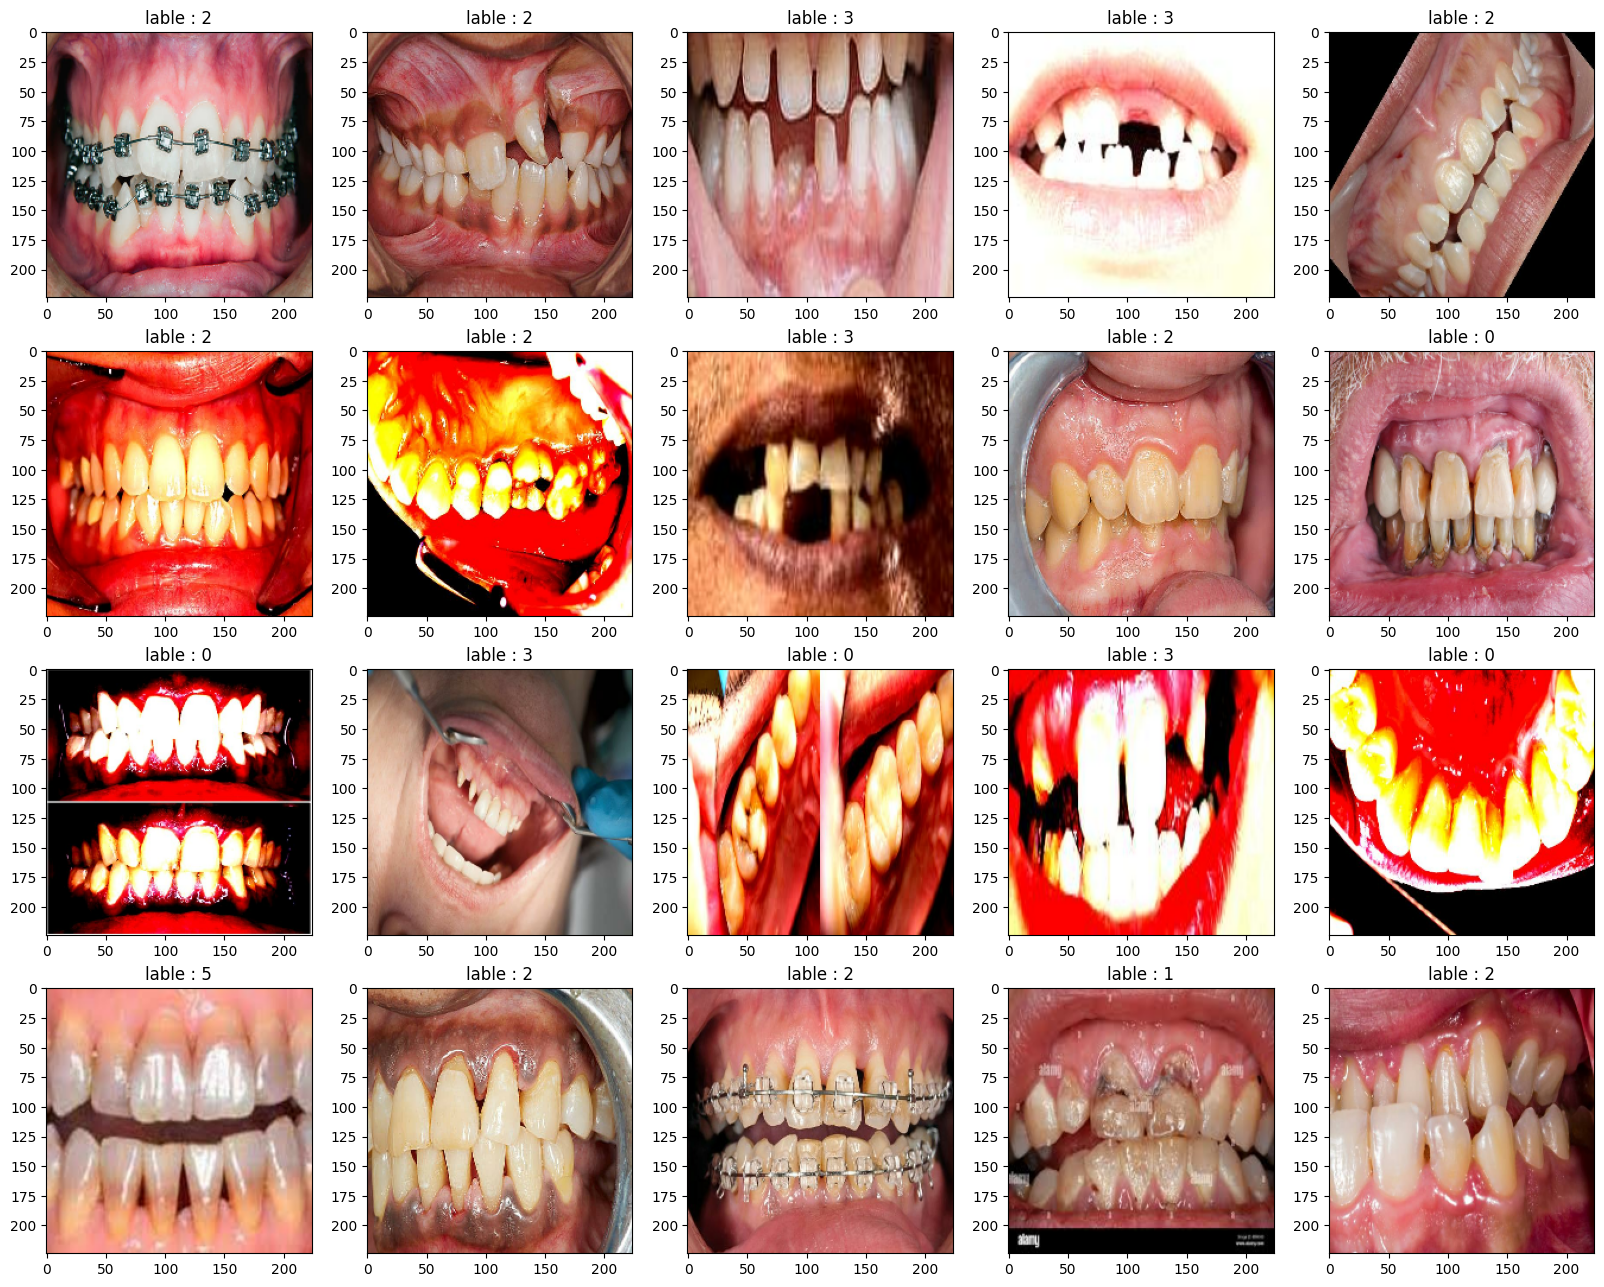

In [20]:
for images , labels in train_ds . take(1) :
    plt.figure (figsize = (20,20))
    for i in range (20):
        ax = plt.subplot(5,5,i+1)
        plt.imshow (images[i].numpy().astype("uint8"))
        plt.title(f'lable : {labels[i].numpy()}')

plt.show()
    

In [21]:
for images , labels in train_ds . take(1) :
    print(f"images shape : {images.shape }")
    print (f"lable : {labels . shape} ")
    print (f"lable : {labels . numpy()} ")
class_names = train_ds.class_names
print("Classes:", class_names)

images shape : (32, 224, 224, 3)
lable : (32,) 
lable : [2 0 3 0 0 1 0 2 0 2 3 0 4 2 5 3 0 0 2 2 2 2 2 2 3 0 2 5 1 2 2 3] 
Classes: ['Calculus', 'Caries', 'Gingivitis', 'Hypodontia', 'Mouth_Ulcer', 'Tooth_Discoloration']


# Data Pipeline Optimization

In [22]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


# Data Augmentation

In [23]:


img_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.2),
    layers.GaussianNoise(0.05),
]
,name = 'img_augmentation'
)

# callbacks

In [24]:
lr_callback = callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.1,
    patience=8,
    mode='max',
    verbose=1
)

stop_callbacks = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

model_ckp = callbacks.ModelCheckpoint(
    "Custom_cnn_best_weights.keras",
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# CNN Build

```mermaid
flowchart TD
    A["Input<br/>224 × 224 × 3"] --> B

    subgraph B["Block 1"]
        B1["Conv2D 32"]
        B2["BatchNorm + ReLU"]
        B3["Conv2D 32"]
        B4["BatchNorm + ReLU"]
        B5["MaxPooling"]
        B6["Dropout 0.20"]
        B1 --> B2 --> B3 --> B4 --> B5 --> B6
    end

    B --> C

    subgraph C["Block 2"]
        C1["Conv2D 64"]
        C2["BatchNorm + ReLU"]
        C3["Conv2D 64"]
        C4["BatchNorm + ReLU"]
        C5["MaxPooling"]
        C6["Dropout 0.25"]
        C1 --> C2 --> C3 --> C4 --> C5 --> C6
    end

    C --> D

    subgraph D["Block 3"]
        D1["Conv2D 128"]
        D2["BatchNorm + ReLU"]
        D3["Conv2D 128"]
        D4["BatchNorm + ReLU"]
        D5["MaxPooling"]
        D6["Dropout 0.30"]
        D1 --> D2 --> D3 --> D4 --> D5 --> D6
    end

    D --> E

    subgraph E["Block 4"]
        E1["Conv2D 256"]
        E2["BatchNorm + ReLU"]
        E3["Conv2D 256"]
        E4["BatchNorm + ReLU"]
        E5["MaxPooling"]
        E6["Dropout 0.35"]
        E1 --> E2 --> E3 --> E4 --> E5 --> E6
    end

    E --> F["GlobalAveragePooling2D"]
    F --> G["Dense 256 + ReLU + L2"]
    G --> H["BatchNormalization"]
    H --> I["Dropout 0.50"]
    I --> J["Dense 6 + Softmax"]

    J --> K["6 Classes"]

In [25]:

def cnn_build(input_shape=(224, 224, 3), num_classes=6):
    model = Sequential([
        Input(shape=input_shape),
        img_augmentation,
        layers.Rescaling(1./255),

        # Block 1
        layers.Conv2D(32, (3,3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(32, (3,3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.20),

        # Block 2
        layers.Conv2D(64, (3,3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(64, (3,3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(128, (3,3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.30),

        # Block 4
        layers.Conv2D(256, (3,3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(256, (3,3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.35),

        # Classification Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(num_classes, activation="softmax")
    ], name="Custom_CNN")
    return model

model = cnn_build(input_shape=(image_width, image_hight, 3), num_classes=num_classes)
model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ img_augmentation (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,244,454 (4.75 MB)

 Trainable params: 1,242,022 (4.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

## Compile 

In [26]:
def cnn_build_tunable(learning_rate=1e-3, head_dropout=0.5):
    m = cnn_build(input_shape=(image_width, image_hight, 3), num_classes=num_classes)
    m.compile(optimizer=Adam(learning_rate=learning_rate),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

tuning_results = []
for lr in [1e-3, 1e-4]:
    for do in [0.3, 0.5]:
        m = cnn_build_tunable(learning_rate=lr, head_dropout=do)
        h = m.fit(train_ds, validation_data=val_ds, epochs=8,
                  class_weight=class_weights, verbose=0)
        tuning_results.append({'learning_rate': lr, 'dropout': do,
                                'best_val_accuracy': max(h.history['val_accuracy'])})

tuning_df = pd.DataFrame(tuning_results).sort_values('best_val_accuracy', ascending=False)
tuning_df

E0000 00:00:1788410805.800785      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Custom_CNN_1/dropout_5_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1788411235.334041      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Custom_CNN_1/dropout_10_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1788411656.675455      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Custom_CNN_1/dropout_15_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1788412081.070780      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape in

,learning_rate,dropout,best_val_accuracy
1,0.0010,0.5,0.488789
0,0.0010,0.3,0.408969
2,0.0001,0.3,0.363229
3,0.0001,0.5,0.223318


In [27]:
best_lr = tuning_df.iloc[0]['learning_rate']

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# The Model

In [28]:

csv_logger = keras.callbacks.CSVLogger("custom_CNN_model_logs.csv", append=False)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    class_weight=class_weights,
    callbacks=[
        lr_callback,
        stop_callbacks,
        model_ckp,
        csv_logger  
    ]
)

Epoch 1/200


E0000 00:00:1788412505.724658      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Custom_CNN_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.1888 - loss: 2.2856
Epoch 1: val_accuracy improved from None to 0.04753, saving model to Custom_cnn_best_weights.keras

Epoch 1: finished saving model to Custom_cnn_best_weights.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 59s 381ms/step - accuracy: 0.1817 - loss: 2.1759 - val_accuracy: 0.0475 - val_loss: 2.3166 - learning_rate: 0.0010
Epoch 2/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.1755 - loss: 1.9857
Epoch 2: val_accuracy did not improve from 0.04753
139/139 ━━━━━━━━━━━━━━━━━━━━ 51s 369ms/step - accuracy: 0.1871 - loss: 1.9076 - val_accuracy: 0.0475 - val_loss: 2.5840 - learning_rate: 0.0010
Epoch 3/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.2177 - loss: 1.7643
Epoch 3: val_accuracy improved from 0.04753 to 0.12825, saving model to Custom_cnn_best_weights.keras

Epoch 3: finished saving model to Custom_cnn_best_weights.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 52s 375ms/step - accuracy: 0.2487 - loss: 1.72

In [29]:
results = {}
model_checkpoint_paths = {}

def evaluate_and_store(model_name, history, trained_model, val_ds):
    val_loss, val_acc = trained_model.evaluate(val_ds, verbose=0)

    y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)
    y_pred = np.argmax(trained_model.predict(val_ds, verbose=0), axis=1)

    f1 = f1_score(y_true, y_pred, average='macro')

    results[model_name] = {
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'f1_macro': f1,
        'history': history.history,
        'y_true': y_true,
        'y_pred': y_pred
    }
    print(f"{model_name} -> val_accuracy: {val_acc:.4f} | val_loss: {val_loss:.4f} | f1_macro: {f1:.4f}")

evaluate_and_store("Custom_CNN", history, model, val_ds)
model_checkpoint_paths["Custom_CNN"] = "Custom_cnn_best_weights.keras"

Custom_CNN -> val_accuracy: 0.6538 | val_loss: 0.8506 | f1_macro: 0.5931


# pretrained model

In [30]:
def build_transfer_model(base_model_fn, preprocess_fn, name,
                          input_shape=(224,224,3), num_classes=6,
                          dense_units=256, dropout=0.5,
                          learning_rate=1e-3, fine_tune_at=None):

    base_model = base_model_fn(include_top=False, weights="imagenet", input_shape=input_shape)

    if fine_tune_at is None:
        base_model.trainable = False          # feature extraction
    else:
        base_model.trainable = True           # fine-tuning 
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = Input(shape=input_shape)
    x = img_augmentation(inputs)
    x = layers.Lambda(preprocess_fn)(x)
    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    tf_model = Model(inputs, outputs, name=name)
    tf_model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return tf_model

# EfficientNetB0

In [31]:
model_name = "EfficientNetB0"
checkpoint_path = f"{model_name}_best.keras"

efficientnet_model = build_transfer_model(
    base_model_fn=EfficientNetB0,
    preprocess_fn=effnet_preprocess,
    name=model_name,
    input_shape=(image_width, image_hight, 3),
    num_classes=num_classes,
    learning_rate=1e-3
)

lr_cb  = callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=5, mode='max', verbose=1)
es_cb  = callbacks.EarlyStopping(monitor='val_accuracy', patience=8, mode='max', restore_best_weights=True, verbose=1)
ckp_cb = callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max')
log_cb = keras.callbacks.CSVLogger(f"{model_name}_logs.csv", append=False)

history_effnet = efficientnet_model.fit(
    train_ds, validation_data=val_ds, epochs=40,
    class_weight=class_weights,
    callbacks=[lr_cb, es_cb, ckp_cb, log_cb]
)

evaluate_and_store(model_name, history_effnet, efficientnet_model, val_ds)
model_checkpoint_paths[model_name] = checkpoint_path

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40


E0000 00:00:1788414592.642080      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


139/139 ━━━━━━━━━━━━━━━━━━━━ 29s 129ms/step - accuracy: 0.4930 - loss: 1.4987 - val_accuracy: 0.6709 - val_loss: 0.9085 - learning_rate: 0.0010
Epoch 2/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.6052 - loss: 0.9774 - val_accuracy: 0.6359 - val_loss: 0.9235 - learning_rate: 0.0010
Epoch 3/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.6392 - loss: 0.8404 - val_accuracy: 0.6942 - val_loss: 0.8073 - learning_rate: 0.0010
Epoch 4/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - accuracy: 0.6709 - loss: 0.7878 - val_accuracy: 0.6933 - val_loss: 0.8079 - learning_rate: 0.0010
Epoch 5/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.6877 - loss: 0.7237 - val_accuracy: 0.7112 - val_loss: 0.7370 - learning_rate: 0.0010
Epoch 6/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.6963 - loss: 0.6942 - val_accuracy: 0.7336 - val_loss: 0.6794 - learning_rate: 0.0010
Epoch 7/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - accuracy: 0.7010 - loss: 0

# ResNet50

In [32]:
model_name = "ResNet50"
checkpoint_path = f"{model_name}_best.keras"

resnet_model = build_transfer_model(
    base_model_fn=ResNet50,
    preprocess_fn=resnet_preprocess,
    name=model_name,
    input_shape=(image_width, image_hight, 3),
    num_classes=num_classes,
    learning_rate=1e-3
)

lr_cb  = callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=5, mode='max', verbose=1)
es_cb  = callbacks.EarlyStopping(monitor='val_accuracy', patience=8, mode='max', restore_best_weights=True, verbose=1)
ckp_cb = callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max')
log_cb = keras.callbacks.CSVLogger(f"{model_name}_logs.csv", append=False)

history_resnet = resnet_model.fit(
    train_ds, validation_data=val_ds, epochs=40,
    class_weight=class_weights,
    callbacks=[lr_cb, es_cb, ckp_cb, log_cb]
)

evaluate_and_store(model_name, history_resnet, resnet_model, val_ds)
model_checkpoint_paths[model_name] = checkpoint_path

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 38s 216ms/step - accuracy: 0.5106 - loss: 1.3865 - val_accuracy: 0.6700 - val_loss: 0.8924 - learning_rate: 0.0010
Epoch 2/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 36s 189ms/step - accuracy: 0.6230 - loss: 0.9321 - val_accuracy: 0.6888 - val_loss: 0.8217 - learning_rate: 0.0010
Epoch 3/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 26s 188ms/step - accuracy: 0.6628 - loss: 0.8010 - val_accuracy: 0.7283 - val_loss: 0.7145 - learning_rate: 0.0010
Epoch 4/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 180ms/step - accuracy: 0.6871 - loss: 0.7125 - val_accuracy: 0.7067 - val_loss: 0.7924 - learning_rate: 0.0010
Epoch 5/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 26s 189ms/step - accuracy: 0.7118 - loss: 0.6742 - val_accuracy: 0.7534 - val_loss: 0.6300 - learning_rate: 0.0010
Epoch 6/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 183ms/step - accuracy: 0.7311 - loss: 0.5964 - val_accuracy: 0.7381 - val_loss: 0.6569 - learning_rate: 0.0010
Epoch 7/40
139/139 

# MobileNetV2

In [33]:
model_name = "MobileNetV2"
checkpoint_path = f"{model_name}_best.keras"

mobilenet_model = build_transfer_model(
    base_model_fn=MobileNetV2,
    preprocess_fn=mobilenet_preprocess,
    name=model_name,
    input_shape=(image_width, image_hight, 3),
    num_classes=num_classes,
    learning_rate=1e-3
)

lr_cb  = callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=5, mode='max', verbose=1)
es_cb  = callbacks.EarlyStopping(monitor='val_accuracy', patience=8, mode='max', restore_best_weights=True, verbose=1)
ckp_cb = callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max')
log_cb = keras.callbacks.CSVLogger(f"{model_name}_logs.csv", append=False)

history_mobilenet = mobilenet_model.fit(
    train_ds, validation_data=val_ds, epochs=40,
    class_weight=class_weights,
    callbacks=[lr_cb, es_cb, ckp_cb, log_cb]
)

evaluate_and_store(model_name, history_mobilenet, mobilenet_model, val_ds)
model_checkpoint_paths[model_name] = checkpoint_path

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - accuracy: 0.4921 - loss: 1.4108 - val_accuracy: 0.6843 - val_loss: 0.7984 - learning_rate: 0.0010
Epoch 2/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.5926 - loss: 0.9472 - val_accuracy: 0.6646 - val_loss: 0.8343 - learning_rate: 0.0010
Epoch 3/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.6459 - loss: 0.8420 - val_accuracy: 0.7139 - val_loss: 0.7160 - learning_rate: 0.0010
Epoch 4/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.6576 - loss: 0.7755 - val_accuracy: 0.7058 - val_loss: 0.7361 - learning_rate: 0.0010
Epoch 5/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.6763 - loss: 0.7072 - val_accuracy: 0.6484 - val_loss: 0.8174 - learning_rate: 0.0010
Epoch 6/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.6814 - loss: 0.6814 - val_accuracy: 0.6996 - val_loss: 0.7412 - learning_rate: 0.0010
Epoch 7/40
139/139 ━━━━━━━━

# Compare

In [34]:
comparison_df = pd.DataFrame([
    {'Model': name, 'Val Accuracy': r['val_accuracy'], 'Val Loss': r['val_loss'], 'F1 (macro)': r['f1_macro']}
    for name, r in results.items()
]).sort_values('F1 (macro)', ascending=False).reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.iloc[0]['Model']
print(f"Best model for production: {best_model_name}")

,Model,Val Accuracy,Val Loss,F1 (macro)
0,ResNet50,0.781166,0.570509,0.775846
1,EfficientNetB0,0.786547,0.581393,0.760413
2,MobileNetV2,0.723767,0.689467,0.701945
3,Custom_CNN,0.653812,0.850597,0.593082


Best model for production: ResNet50


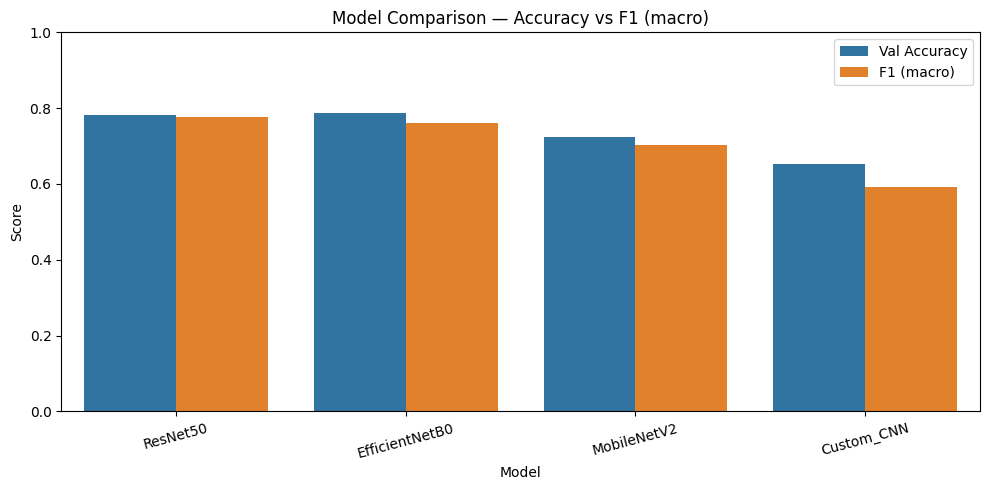

In [35]:
metrics_to_plot = comparison_df.melt(
    id_vars='Model', value_vars=['Val Accuracy', 'F1 (macro)'],
    var_name='Metric', value_name='Score'
)

plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_to_plot, x='Model', y='Score', hue='Metric')
plt.ylim(0, 1)
plt.title('Model Comparison — Accuracy vs F1 (macro)')
plt.xticks(rotation=15)
plt.legend(title='')
plt.tight_layout()
plt.show()

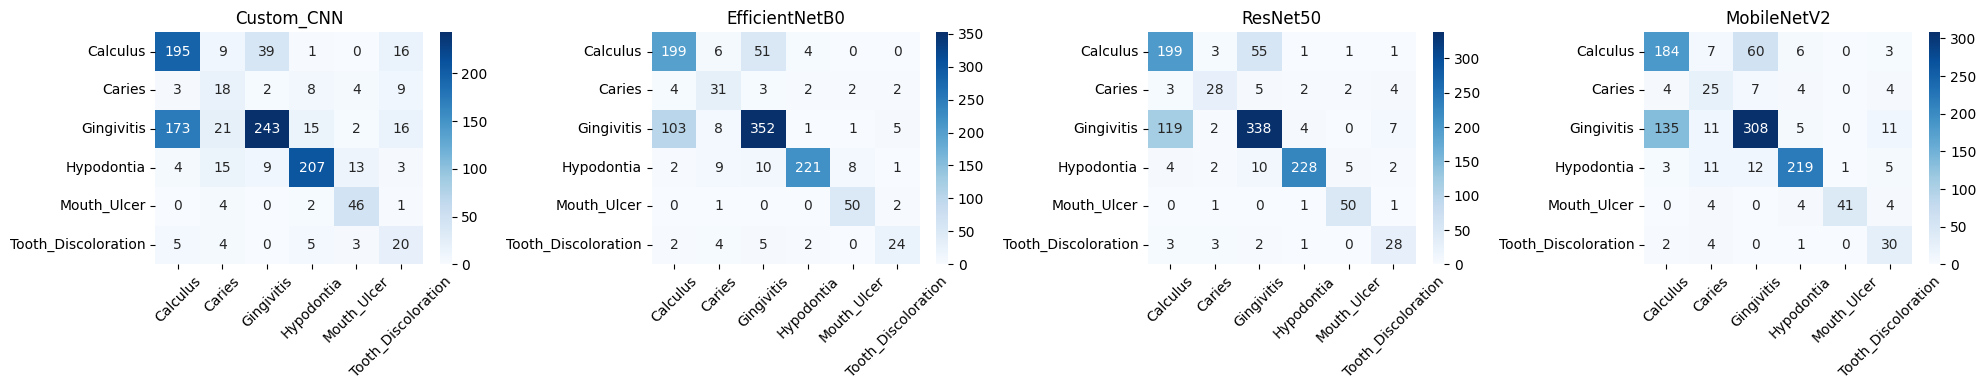

In [36]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# import best Model

In [37]:
production_dir = "/kaggle/working/production_model"
os.makedirs(production_dir, exist_ok=True)


best_checkpoint_src = model_checkpoint_paths[best_model_name]
best_checkpoint_dst = os.path.join(production_dir, "model.keras")
shutil.copy2(best_checkpoint_src, best_checkpoint_dst)


preprocess_map = {
    "Custom_CNN": "none",
    "EfficientNetB0": "efficientnet",
    "ResNet50": "resnet50",
    "MobileNetV2": "mobilenet_v2",
}

metadata = {
    "model_name": best_model_name,
    "image_size": [image_width, image_hight],
    "class_names": class_names,
    "preprocessing": preprocess_map[best_model_name],
    "val_accuracy": float(results[best_model_name]['val_accuracy']),
    "val_loss": float(results[best_model_name]['val_loss']),
    "f1_macro": float(results[best_model_name]['f1_macro']),
}

with open(os.path.join(production_dir, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(" Production package saved to:", production_dir)
print(json.dumps(metadata, indent=2, ensure_ascii=False))

 Production package saved to: /kaggle/working/production_model
{
  "model_name": "ResNet50",
  "image_size": [
    224,
    224
  ],
  "class_names": [
    "Calculus",
    "Caries",
    "Gingivitis",
    "Hypodontia",
    "Mouth_Ulcer",
    "Tooth_Discoloration"
  ],
  "preprocessing": "resnet50",
  "val_accuracy": 0.7811658978462219,
  "val_loss": 0.5705086588859558,
  "f1_macro": 0.7758464153451597
}


In [38]:


production_dir = '/kaggle/working/production_model_package'
os.makedirs(production_dir, exist_ok=True)


model_path = os.path.join(production_dir, 'oral_disease_model.h5')
final_cnn_model.save(model_path)


labels_path = os.path.join(production_dir, 'labels.txt')
with open(labels_path, 'w') as f:
    for cls in class_names:
        f.write(f"{cls}\n")


shutil.make_archive("/kaggle/working/production_model_package", 'zip', production_dir)

print("Save production_model_package.zip")

'/kaggle/working/production_model_package.zip'